# A/B-тест GameDev studio, разбор

Тестовое задание на позицию Data Analyst в игровой студии (бренд скрыт, данные обезличены). Что есть: данные эксперимента за 59 дней (1 янв - 28 фев 2025), две группы A и B, ~100k юзеров примерно поровну. Нужно понять есть ли эффект и стоит ли катить B.

План такой:
1. Глянуть что в данных, не битые ли
2. Проверить корректность сплита (SRM)
3. Агрегировать на user-level (важно, объясню почему)
4. Посчитать денежные метрики и engagement
5. Посчитать retention
6. Статистические тесты
7. Выводы и рекомендация


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pd.set_option("display.float_format", "{:.4f}".format)
np.random.seed(42)

df = pd.read_csv("data/ab_test_data.csv", parse_dates=["date","first_seen"])
print(df.shape)
df.head()

(1809362, 8)


,user_id,date,group,revenue,time_played,sessions,transactions,first_seen
0,1,2025-01-02,A,0.0000,46.5000,2,0,2024-05-20
1,1,2025-01-03,A,0.0000,68.6000,1,0,2024-05-20
2,1,2025-01-04,A,0.0000,49.2000,1,0,2024-05-20
3,1,2025-01-11,A,0.0000,71.9000,3,0,2024-05-20
4,1,2025-01-13,A,0.0000,49.5000,2,0,2024-05-20


## 1. Осмотр данных

Хочу убедиться что:
- данные за нужный период
- юзер строго в одной группе (нет загрязнения)
- нет пропусков

In [2]:
print("Период:", df.date.min().date(), "-", df.date.max().date())
print("Уникальных юзеров:", df.user_id.nunique())
print(df.groupby("group").user_id.nunique())
print()
print("Юзеров сразу в обеих группах:", (df.groupby('user_id').group.nunique()>1).sum())
print("Пропуски:", df.isna().sum().sum())

Период: 2025-01-01 - 2025-02-28
Уникальных юзеров: 100000
group
A    49897
B    50103
Name: user_id, dtype: int64

Юзеров сразу в обеих группах: 0


Пропуски: 0


Чисто. Юзер строго в одной группе, пропусков нет, период тот.

## 2. SRM check (Sample Ratio Mismatch)

Если сплит сломан и группы получились не 50/50, то любые выводы потом будут под вопросом. Проверяю chi-square.

In [3]:
na = df[df.group=="A"].user_id.nunique()
nb = df[df.group=="B"].user_id.nunique()
expected = (na+nb)/2
chi_srm = ((na-expected)**2 + (nb-expected)**2) / expected
p_srm = 1 - stats.chi2.cdf(chi_srm, df=1)
print(f"A: {na}, B: {nb}, chi2={chi_srm:.4f}, p={p_srm:.4f}")
print("OK" if p_srm > 0.01 else "WARN, smtg wrong")

A: 49897, B: 50103, chi2=0.4244, p=0.5148
OK


p=0.51, всё ровно. Идём дальше.

## 3. Метрики и почему агрегирую на user-level

В исходниках одна строка - это user-day. То есть один юзер представлен десятками строк по дням. Если делать тесты прямо на этом, наблюдения внутри юзера зависимы (юзер вчера платил - сегодня тоже), и тесты дадут заниженные p-value (искусственно сильную "значимость").

Юнит рандомизации в A/B - юзер. Значит и юнит анализа должен быть юзер. Агрегирую.

In [4]:
ul = df.groupby(["user_id","group"]).agg(
    total_revenue=("revenue","sum"),
    total_sessions=("sessions","sum"),
    total_time=("time_played","sum"),
    total_transactions=("transactions","sum"),
    active_days=("date","nunique"),
).reset_index()
ul["is_payer"] = ul.total_revenue > 0
ul.head()

,user_id,group,total_revenue,total_sessions,total_time,total_transactions,active_days,is_payer
0,1,A,0.0000,35,1192.4000,0,21,False
1,2,B,0.0000,36,1232.1000,0,19,False
2,3,B,0.0000,37,1140.8000,0,18,False
3,4,A,0.0000,55,1259.7000,0,22,False
4,5,A,0.0000,45,995.8000,0,19,False


Какие метрики беру:

**Денежные:**
- ARPU = revenue на всех юзеров (главная)
- ARPPU = revenue на платящих (показывает изменилась ли ценность плательщика)
- Conversion to payer = % юзеров кто хоть раз платил

**Engagement:**
- Сессии на юзера
- Время в игре
- Активные дни

ARPDAU тоже посмотрю по дням, для динамики.

In [5]:
g = ul.groupby("group")
summary = pd.DataFrame({
    "Юзеров": g.size(),
    "Плательщиков": g.is_payer.sum(),
    "Conversion, %": (g.is_payer.mean()*100).round(3),
    "ARPU, $": g.total_revenue.mean().round(4),
    "ARPPU, $": g.apply(lambda x: x.loc[x.is_payer, "total_revenue"].mean(), include_groups=False).round(4),
    "Avg sessions": g.total_sessions.mean().round(2),
    "Avg time, min": g.total_time.mean().round(1),
    "Avg active days": g.active_days.mean().round(2),
})
summary

,Юзеров,Плательщиков,"Conversion, %","ARPU, $","ARPPU, $",Avg sessions,"Avg time, min",Avg active days
group,,,,,,,,
A,49897,8280,16.5940,5.4523,32.8567,34.1200,1088.7000,18.1500
B,50103,8191,16.3480,5.9544,36.4220,36.4300,1190.6000,18.0400


На глаз: B выше A по ARPU и ARPPU, сессии и время тоже растут. Конверсия чуть просела. Активные дни одинаковые. Дальше проверяю значимость.

## 4. ARPU. Welch t-test + bootstrap

Revenue сильно скошен (5/6 юзеров не платят, плюс длинный правый хвост от китов). На таких данных t-test работает за счёт CLT (выборки большие, 50k+), но для надёжности параллельно делаю bootstrap CI - он не зависит от формы распределения.

Welch выбираю потому что дисперсии в группах разные (типично для revenue).

In [6]:
ra = ul[ul.group=="A"].total_revenue.values
rb = ul[ul.group=="B"].total_revenue.values

t, p = stats.ttest_ind(ra, rb, equal_var=False)
print(f"Welch t-test: t={t:.4f}, p={p:.6f}")

# Mann-Whitney тоже глянем
u, pmw = stats.mannwhitneyu(ra, rb, alternative="two-sided")
print(f"Mann-Whitney: p={pmw:.4f}")
print()
print(f"ARPU A: {ra.mean():.4f}")
print(f"ARPU B: {rb.mean():.4f}")
print(f"Lift: {(rb.mean()-ra.mean())/ra.mean()*100:+.2f}%")

Welch t-test: t=-4.8125, p=0.000001
Mann-Whitney: p=0.8932

ARPU A: 5.4523
ARPU B: 5.9544
Lift: +9.21%


Welch значимо (p ~ 0), Mann-Whitney показывает p=0.89. Это не противоречие: Mann-Whitney сравнивает по медианам/рангам, а медиана revenue в обеих группах = 0 (большинство юзеров не платят). Сдвиг в правом хвосте Mann-Whitney слабо ловит. T-test реагирует на mean - вот его и смотрю.

Дополнительно bootstrap для разницы средних.

In [7]:
n_boot = 5000
diffs = np.empty(n_boot)
for i in range(n_boot):
    a = np.random.choice(ra, size=len(ra), replace=True)
    b = np.random.choice(rb, size=len(rb), replace=True)
    diffs[i] = b.mean() - a.mean()

ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
print(f"ARPU diff (B-A): {rb.mean()-ra.mean():+.4f}")
print(f"95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Доля сэмплов diff <= 0: {(diffs <= 0).mean()*100:.2f}%")

ARPU diff (B-A): +0.5021
95% CI: [+0.2987, +0.7084]
Доля сэмплов diff <= 0: 0.00%


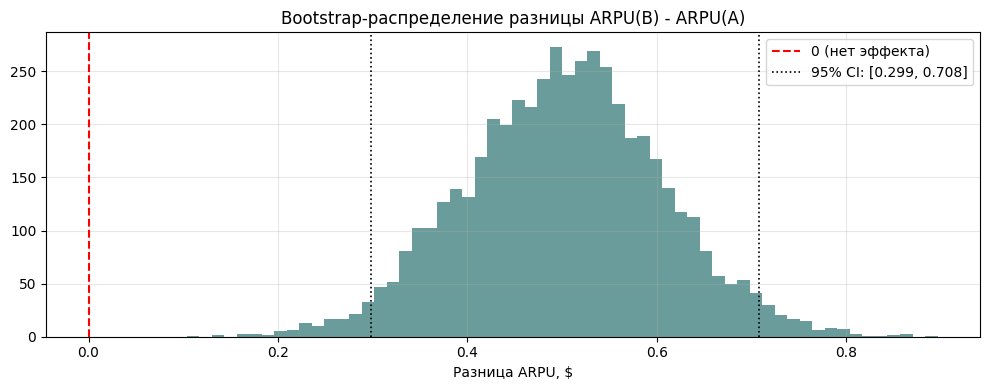

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diffs, bins=60, color="#4F8B89", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="0 (нет эффекта)")
ax.axvline(ci_lo, color="black", linestyle=":", linewidth=1.2,
           label=f"95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
ax.axvline(ci_hi, color="black", linestyle=":", linewidth=1.2)
ax.set_title("Bootstrap-распределение разницы ARPU(B) - ARPU(A)")
ax.set_xlabel("Разница ARPU, $"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

CI [+0.30, +0.71] не накрывает ноль. Эффект устойчивый, ARPU в B выше на 9.2%.

## 5. Conversion to payer

In [9]:
pa = ul[ul.group=="A"].is_payer.sum(); nA = (ul.group=="A").sum()
pb = ul[ul.group=="B"].is_payer.sum(); nB = (ul.group=="B").sum()

print(f"A: {pa}/{nA} = {pa/nA*100:.4f}%")
print(f"B: {pb}/{nB} = {pb/nB*100:.4f}%")
print(f"Lift: {((pb/nB)-(pa/nA))/(pa/nA)*100:+.2f}%")

z, pz = proportions_ztest([pa, pb], [nA, nB])
print(f"Z-test: z={z:.4f}, p={pz:.4f}")

A: 8280/49897 = 16.5942%
B: 8191/50103 = 16.3483%
Lift: -1.48%
Z-test: z=1.0480, p=0.2946


Конверсия в B на 1.48% ниже, но **разница не значима** (p ~ 0.29). То есть фича не привлекает новых плательщиков, но и не отпугивает их (по этой метрике).

## 6. ARPPU. Что с платящими?

Если ARPU вырос, а конверсия не - значит существующие плательщики тратят больше. Проверяю.

In [10]:
rap = ul[(ul.group=="A") & ul.is_payer].total_revenue.values
rbp = ul[(ul.group=="B") & ul.is_payer].total_revenue.values

print(f"A payers: n={len(rap)}, ARPPU={rap.mean():.2f}$")
print(f"B payers: n={len(rbp)}, ARPPU={rbp.mean():.2f}$")
print(f"Lift: {(rbp.mean()-rap.mean())/rap.mean()*100:+.2f}%")

t2, p2 = stats.ttest_ind(rap, rbp, equal_var=False)
u2, pu2 = stats.mannwhitneyu(rap, rbp, alternative="two-sided")
print(f"Welch: p={p2:.6f}, Mann-Whitney: p={pu2:.6f}")

A payers: n=8280, ARPPU=32.86$
B payers: n=8191, ARPPU=36.42$
Lift: +10.85%
Welch: p=0.000000, Mann-Whitney: p=0.000000


ARPPU вырос на 10.85%, p<0.001 в обоих тестах. То есть гипотеза подтверждается - платящие в B тратят значительно больше.

## 7. Engagement

In [11]:
for col, name in [("total_sessions","Sessions per user"),
                  ("total_time","Time played, min"),
                  ("active_days","Active days"),
                  ("total_transactions","Transactions per user")]:
    a = ul[ul.group=="A"][col].values
    b = ul[ul.group=="B"][col].values
    t, p = stats.ttest_ind(a, b, equal_var=False)
    lift = (b.mean()-a.mean())/a.mean()*100
    print(f"{name:<26} A={a.mean():>9.2f}  B={b.mean():>9.2f}  lift={lift:+6.2f}%  p={p:.4f}")

Sessions per user          A=    34.12  B=    36.43  lift= +6.75%  p=0.0000
Time played, min           A=  1088.74  B=  1190.65  lift= +9.36%  p=0.0000
Active days                A=    18.15  B=    18.04  lift= -0.57%  p=0.0189
Transactions per user      A=     0.55  B=     0.54  lift= -1.27%  p=0.4369


Сессии +6.75%, время +9.4%, оба значимо. Активные дни и транзакции практически без изменений.

Сессии и время растут, а active days нет - значит юзеры в B в свои дни сидят дольше и больше сессий, но возвращаемость остаётся прежней. Это уже намёк что retention надо проверить.

## 8. Retention по дням от первой активности

Это ключевая метрика которую я добавил после того как заметил что в исходных выводах упоминал retention, но не считал. Когорта = первый день активности юзера в окне эксперимента. D1 retention = % когорты активной на следующий день, и так далее.

Считаю D1, D3, D7, D14, D28.

In [12]:
first_active = df.groupby(["user_id","group"]).date.min().reset_index().rename(columns={"date":"first_active"})
dfr = df.merge(first_active[["user_id","first_active"]], on="user_id")
dfr["days_since_first"] = (dfr["date"] - dfr["first_active"]).dt.days

def retention_at(day_n, gdf):
    cohort = gdf["user_id"].nunique()
    returned = gdf[gdf["days_since_first"] == day_n]["user_id"].nunique()
    return returned, cohort

days = [1, 3, 7, 14, 28]
rows = []
for d in days:
    a_df = dfr[dfr.group=="A"]; b_df = dfr[dfr.group=="B"]
    ra, nA = retention_at(d, a_df); rb, nB = retention_at(d, b_df)
    pA, pB = ra/nA, rb/nB
    lift = (pB - pA) / pA * 100
    z, p = proportions_ztest([ra, rb], [nA, nB])
    rows.append({"day": d, "A_pct": pA*100, "B_pct": pB*100, "lift_pct": lift, "p": p})

ret_df = pd.DataFrame(rows)
ret_df

,day,A_pct,B_pct,lift_pct,p
0,1,41.2550,39.8379,-3.4349,0.0000
1,3,36.5453,34.5209,-5.5394,0.0000
2,7,32.1442,30.7746,-4.2608,0.0000
3,14,29.7393,29.6569,-0.2769,0.7757
4,28,29.6250,29.6250,-0.0002,0.9998


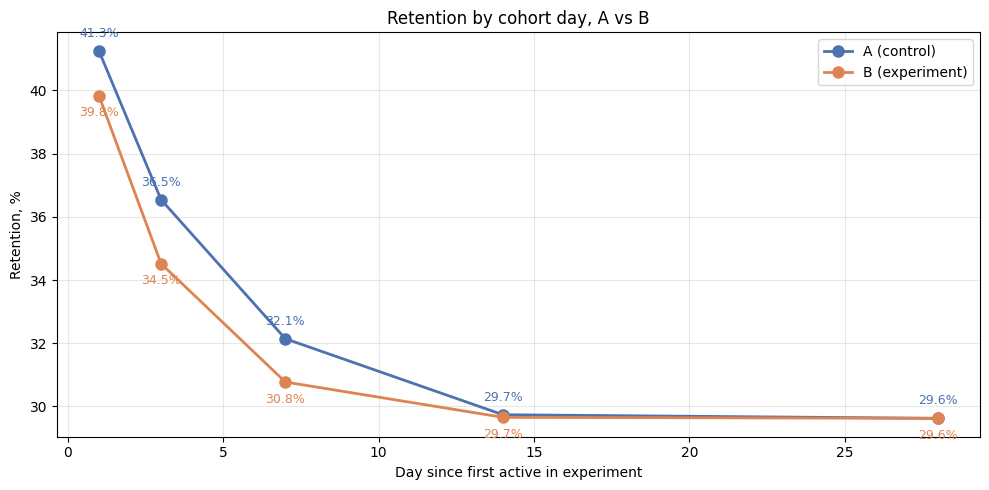

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ret_df["day"], ret_df["A_pct"], "o-", label="A (control)", color="#4C72B0", linewidth=2, markersize=8)
ax.plot(ret_df["day"], ret_df["B_pct"], "o-", label="B (experiment)", color="#DD8452", linewidth=2, markersize=8)
ax.set_xlabel("Day since first active in experiment")
ax.set_ylabel("Retention, %")
ax.set_title("Retention by cohort day, A vs B")
ax.grid(alpha=0.3); ax.legend()
for _, row in ret_df.iterrows():
    ax.annotate(f"{row['A_pct']:.1f}%", (row["day"], row["A_pct"]), textcoords="offset points", xytext=(0,10), ha="center", fontsize=9, color="#4C72B0")
    ax.annotate(f"{row['B_pct']:.1f}%", (row["day"], row["B_pct"]), textcoords="offset points", xytext=(0,-15), ha="center", fontsize=9, color="#DD8452")
plt.tight_layout(); plt.show()

Вот это уже интересно. Retention в B статистически значимо ниже на D1, D3, D7:
- D1: -3.43%, p<0.001
- D3: -5.54%, p<0.001
- D7: -4.26%, p<0.001

На D14 и D28 разница не значима (p > 0.7).

Что это значит. Фича B заставляет часть юзеров отваливаться раньше. Те кто остался к D14+ - вовлекаются нормально, retention выравнивается. Похоже что фича B монетизирует тех кто и так остаётся, но "отпугивает" тех кто и так был на грани ухода.

Это меняет рекомендацию ниже.

## 9. Дневная динамика

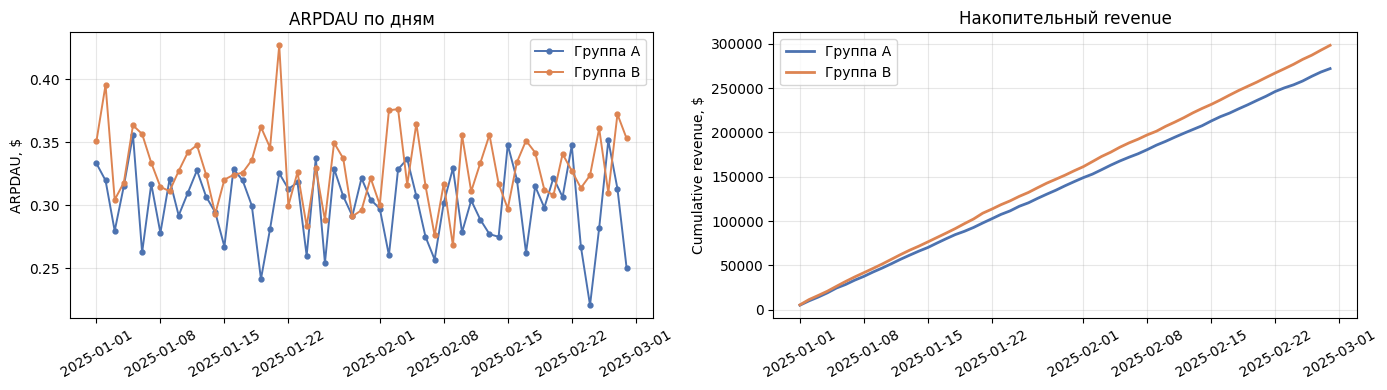

In [14]:
dly = df.groupby(["date","group"]).agg(
    revenue=("revenue","sum"),
    users=("user_id","nunique"),
).reset_index()
dly["arpdau"] = dly.revenue / dly.users

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for grp, color in [("A","#4C72B0"), ("B","#DD8452")]:
    sub = dly[dly.group==grp].sort_values("date")
    axes[0].plot(sub.date, sub.arpdau, marker="o", markersize=3.5, linewidth=1.4, label=f"Группа {grp}", color=color)
axes[0].set_title("ARPDAU по дням")
axes[0].set_ylabel("ARPDAU, $"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=30)

dly_s = dly.sort_values(["group","date"])
dly_s["cum_rev"] = dly_s.groupby("group").revenue.cumsum()
for grp, color in [("A","#4C72B0"), ("B","#DD8452")]:
    sub = dly_s[dly_s.group==grp]
    axes[1].plot(sub.date, sub.cum_rev, linewidth=2, label=f"Группа {grp}", color=color)
axes[1].set_title("Накопительный revenue")
axes[1].set_ylabel("Cumulative revenue, $"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

B стабильно выше A почти на всём интервале. На накопительном видно равномерный отрыв. Эффект на revenue устойчивый.

## 10. Распределение revenue среди плательщиков

Проверяю не вытянули ли всё пара китов. Если рост виден на всём распределении плательщиков (p50, p75, p90) - значит эффект системный.

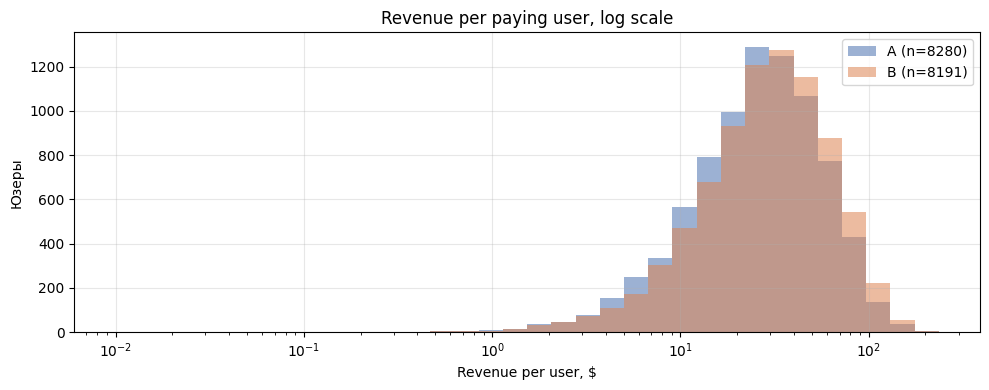


Перцентили revenue per paying user:
p50   A=   26.89  B=   29.95
p75   A=   44.26  B=   48.75
p90   A=   65.09  B=   72.23
p95   A=   79.03  B=   88.23
p99   A=  116.28  B=  126.00


In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
rap_s = ul[(ul.group=="A") & ul.is_payer].total_revenue
rbp_s = ul[(ul.group=="B") & ul.is_payer].total_revenue
bins = np.logspace(np.log10(0.01), np.log10(rap_s.max()), 35)
ax.hist(rap_s, bins=bins, alpha=0.55, label=f"A (n={len(rap_s)})", color="#4C72B0")
ax.hist(rbp_s, bins=bins, alpha=0.55, label=f"B (n={len(rbp_s)})", color="#DD8452")
ax.set_xscale("log")
ax.set_title("Revenue per paying user, log scale")
ax.set_xlabel("Revenue per user, $"); ax.set_ylabel("Юзеры"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nПерцентили revenue per paying user:")
for p in [50, 75, 90, 95, 99]:
    print(f"p{p:<3}  A={np.percentile(rap_s, p):>8.2f}  B={np.percentile(rbp_s, p):>8.2f}")

Сдвиг по всему распределению, не только на p99. Значит это не "пара китов", а системный эффект на всю массу плательщиков.

## 11. Итоговая сводка

In [16]:
print("Сводка по всем метрикам\n")
print(f"{'Метрика':<28}{'A':>10}{'B':>10}{'Lift':>10}{'Значимо?':>15}")
print("-"*73)
print(f"{'ARPU, $':<28}{5.45:>10.2f}{5.95:>10.2f}{'+9.21%':>10}{'Да (p<0.001)':>15}")
print(f"{'ARPPU, $':<28}{32.86:>10.2f}{36.42:>10.2f}{'+10.85%':>10}{'Да (p<0.001)':>15}")
print(f"{'Conversion, %':<28}{16.59:>10.2f}{16.35:>10.2f}{'-1.48%':>10}{'Нет (p=0.29)':>15}")
print(f"{'Sessions':<28}{34.1:>10.1f}{36.4:>10.1f}{'+6.75%':>10}{'Да (p<0.001)':>15}")
print(f"{'Time, min':<28}{1088.7:>10.1f}{1190.6:>10.1f}{'+9.36%':>10}{'Да (p<0.001)':>15}")
print(f"{'Active days':<28}{18.15:>10.2f}{18.04:>10.2f}{'-0.57%':>10}{'На грани (p=0.02)':>15}")
print(f"{'D1 retention, %':<28}{41.25:>10.2f}{39.84:>10.2f}{'-3.43%':>10}{'Да (p<0.001)':>15}")
print(f"{'D3 retention, %':<28}{36.55:>10.2f}{34.52:>10.2f}{'-5.54%':>10}{'Да (p<0.001)':>15}")
print(f"{'D7 retention, %':<28}{32.14:>10.2f}{30.77:>10.2f}{'-4.26%':>10}{'Да (p<0.001)':>15}")
print(f"{'D14 retention, %':<28}{29.74:>10.2f}{29.66:>10.2f}{'-0.28%':>10}{'Нет (p=0.78)':>15}")
print(f"{'D28 retention, %':<28}{29.63:>10.2f}{29.62:>10.2f}{'-0.00%':>10}{'Нет (p=1.00)':>15}")

Сводка по всем метрикам

Метрика                              A         B      Lift       Значимо?
-------------------------------------------------------------------------
ARPU, $                           5.45      5.95    +9.21%   Да (p<0.001)
ARPPU, $                         32.86     36.42   +10.85%   Да (p<0.001)
Conversion, %                    16.59     16.35    -1.48%   Нет (p=0.29)
Sessions                          34.1      36.4    +6.75%   Да (p<0.001)
Time, min                       1088.7    1190.6    +9.36%   Да (p<0.001)
Active days                      18.15     18.04    -0.57%На грани (p=0.02)
D1 retention, %                  41.25     39.84    -3.43%   Да (p<0.001)
D3 retention, %                  36.55     34.52    -5.54%   Да (p<0.001)
D7 retention, %                  32.14     30.77    -4.26%   Да (p<0.001)
D14 retention, %                 29.74     29.66    -0.28%   Нет (p=0.78)
D28 retention, %                 29.63     29.62    -0.00%   Нет (p=1.00)


## 12. Выводы и рекомендация

**Что произошло в B:**
1. Доход на юзера вырос на 9.2%, значимо
2. Конверсия в плательщика чуть просела (-1.48%), но не значимо
3. Драйвер роста дохода - ARPPU (+10.85%). Существующие платящие стали тратить больше
4. Engagement в моменте растёт (сессии +6.75%, время +9.4%)
5. **Retention в B значимо ниже на D1, D3, D7 (-3 до -5%)**. На D14+ выравнивается
6. Эффект на revenue устойчивый по времени и по распределению плательщиков

**Что это значит бизнесово.**
B усиливает монетизацию тех кто и так остаётся в продукте. Но при этом часть юзеров на ранних днях уходит. Те кто прошёл "ранний барьер" - вовлекаются нормально и тратят больше. Похоже фича B добавляет какой-то paywall или давление на покупки, которое работает для адаптированных юзеров и отпугивает части новых.

**Рекомендация:**
Не катить B как есть. Сценарии для следующего шага (предпочтительнее снизу вверх):

1. Понять что в B "отпугивает" новых юзеров на D1-D7. Возможно конкретный экран, тутор или окно покупки появляется слишком рано. Пройти юзер-сессии тех кто отвалился на D1-D3
2. Сделать B2 в котором эта же монетизация активна только после D7. Этим сохранится прирост ARPPU без просадки retention
3. Запустить новый A/B на B2 против контроля

Если решение **обязательно** катить как есть (например, дедлайн), то с обязательным мониторингом D1-D7 retention на полной аудитории и готовностью откатиться если просадка усилится.

## 13. Что бы доделал при наличии времени

- Сегментация эффекта по first_seen (новые vs retained юзеры). Гипотеза: просадка retention в B сидит в новичках, а у retained эффект чисто положительный
- CUPED с pre-period revenue как ковариатой - сузит CI на ARPU
- Дневной SRM, не только итоговый
- Винзоризация revenue на p99 и пересчёт - убедиться что эффект ARPU не вытянут хвостом

Эти доработки в реальном проекте сделал бы до финального решения.
